# Vectors and Embeddings

## What is a Vector?

A **vector** is an ordered list of numbers. In NumPy it's just a 1-D array.
Geometrically it represents a point — or an arrow from the origin — in N-dimensional space.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# A 2-D vector
v = np.array([3.0, 2.0])
print(f'Vector: {v}   Shape: {v.shape}   Dtype: {v.dtype}')

# A 512-D vector — same concept, just not visualisable directly
big_v = np.random.randn(512)
print(f'High-dim vector shape: {big_v.shape}')

Vector: [3. 2.]   Shape: (2,)   Dtype: float64
High-dim vector shape: (512,)


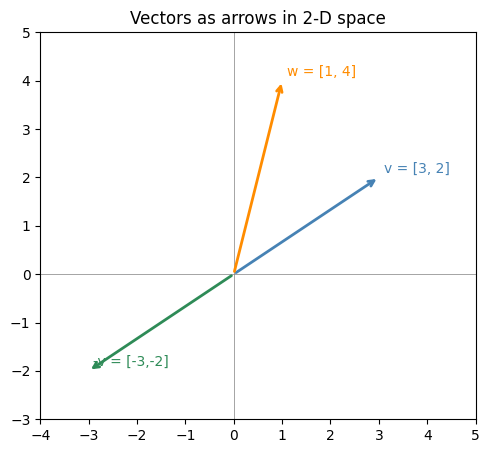

In [ ]:
# Visualise 2-D vectors as arrows from the origin
vectors = {
    'v = [3, 2]' : np.array([3, 2]),
    'w = [1, 4]' : np.array([1, 4]),
    '-v = [-3,-2]': np.array([-3, -2]),
}

fig, ax = plt.subplots(figsize=(5, 5))
colors = ['steelblue', 'darkorange', 'seagreen']
for (label, vec), color in zip(vectors.items(), colors):
    ax.annotate('', xy=vec, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=color, lw=2))
    ax.text(vec[0] + 0.1, vec[1] + 0.1, label, color=color, fontsize=10)
ax.axhline(0, color='grey', lw=0.5)
ax.axvline(0, color='grey', lw=0.5)
ax.set_xlim(-4, 5); ax.set_ylim(-3, 5)
ax.set_aspect('equal')
ax.set_title('Vectors as arrows in 2-D space')
plt.tight_layout()
plt.show()

## Distance Metrics

Given two vectors **a** and **b**, we can measure how far apart they are.
Two common metrics:

| Metric | Formula | When to prefer |
|--------|---------|----------------|
| **Euclidean** | $\\|a - b\\|_2 = \\sqrt{\\sum_i (a_i - b_i)^2}$ | When absolute magnitude matters |
| **Cosine similarity** | $\\frac{a \\cdot b}{\\|a\\| \\cdot \\|b\\|}$ | When only direction (angle) matters |

**Cosine similarity** ignores vector length — two identical vectors scaled by different amounts get similarity = 1.
This matters for embeddings: a brighter image should still be recognised as the same face.

In [ ]:
a = np.array([1.0, 2.0, 3.0])
b = np.array([1.0, 2.1, 2.9])  # slightly different
c = 5 * a                       # same direction as a, 5× longer

def euclidean(x, y):
    return np.sqrt(np.sum((x - y) ** 2))

def cosine_similarity(x, y):
    # Dot product divided by the product of their L2 norms.
    # Range: -1 (opposite) to 1 (identical direction).
    return np.dot(x, y) / (np.linalg.norm(x) * np.linalg.norm(y))

print(f'a vs b  — euclidean: {euclidean(a, b):.3f}  cosine: {cosine_similarity(a, b):.4f}')
print(f'a vs c  — euclidean: {euclidean(a, c):.3f}  cosine: {cosine_similarity(a, c):.4f}')
print()
print('a and c have the same direction → cosine similarity = 1.0 regardless of scale')

a vs b  — euclidean: 0.141  cosine: 0.9993
a vs c  — euclidean: 14.967  cosine: 1.0000

a and c have the same direction → cosine similarity = 1.0 regardless of scale


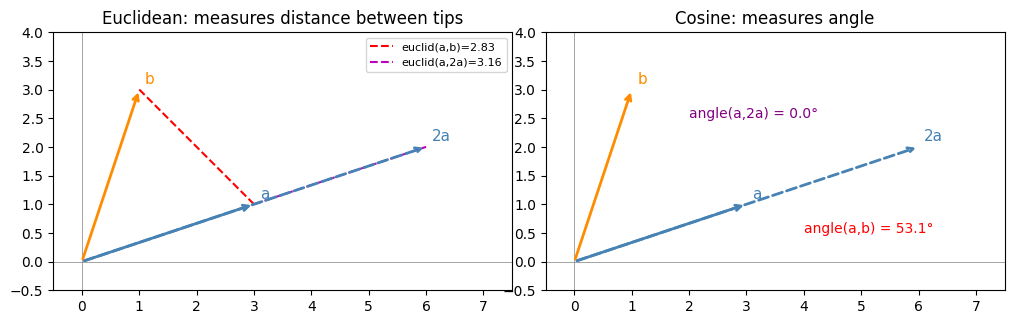

In [ ]:
# Visual demonstration: cosine measures angle, euclidean measures straight-line distance
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

points = {'a': np.array([3, 1]), 'b': np.array([1, 3]), '2a': np.array([6, 2])}
colors = {'a': 'steelblue', 'b': 'darkorange', '2a': 'steelblue'}
styles = {'a': '-', 'b': '-', '2a': '--'}

for label, vec in points.items():
    for ax in axes:
        ax.annotate('', xy=vec, xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color=colors[label],
                                   lw=2, linestyle=styles[label]))
        ax.text(vec[0]+0.1, vec[1]+0.1, label, color=colors[label], fontsize=11)

a2, b2, two_a = points['a'], points['b'], points['2a']

# Euclidean: distance between tips
axes[0].plot([a2[0], b2[0]], [a2[1], b2[1]], 'r--', lw=1.5, label=f'euclid(a,b)={euclidean(a2,b2):.2f}')
axes[0].plot([a2[0], two_a[0]], [a2[1], two_a[1]], 'm--', lw=1.5, label=f'euclid(a,2a)={euclidean(a2,two_a):.2f}')
axes[0].set_title('Euclidean: measures distance between tips')
axes[0].legend(fontsize=8)

# Cosine: measures angle
angle_ab = np.degrees(np.arccos(np.clip(cosine_similarity(a2, b2), -1, 1)))
angle_a2a = np.degrees(np.arccos(np.clip(cosine_similarity(a2, two_a), -1, 1)))
axes[1].set_title('Cosine: measures angle')
axes[1].text(4, 0.5, f'angle(a,b) = {angle_ab:.1f}°', fontsize=10, color='red')
axes[1].text(2, 2.5, f'angle(a,2a) = {angle_a2a:.1f}°', fontsize=10, color='purple')

for ax in axes:
    ax.set_xlim(-0.5, 7.5); ax.set_ylim(-0.5, 4)
    ax.axhline(0, color='grey', lw=0.5); ax.axvline(0, color='grey', lw=0.5)
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

## What are Embeddings?

An **embedding** is a learned mapping from a high-dimensional input (image, text, audio)
to a dense low-dimensional vector in a **semantic space**.

The key property: inputs that are semantically similar are mapped to vectors that are **close**
in that space — as measured by cosine similarity or Euclidean distance.

```
Image of face A → [0.12, -0.34, 0.87, ...]  (512 numbers)
Image of face A (different lighting) → [0.11, -0.33, 0.85, ...]  ← very close!
Image of a car  → [-0.55,  0.21, 0.03, ...]  ← far away
```

This is why embeddings are used for face recognition: instead of comparing pixels
(which change drastically with lighting/angle), we compare **semantic representations**.

## Image Embeddings with CLIP

**CLIP** (Contrastive Language-Image Pre-Training) is a model trained on 400 million
image–text pairs. It learns to map images and text into the *same* 512-dimensional space.

For our purposes we only use the image encoder:
`image → CLIP → 512-D vector`

We use `sentence-transformers` as a convenient wrapper around the CLIP image encoder.

In [ ]:
from PIL import Image
import os
from sentence_transformers import SentenceTransformer

# Load the CLIP image encoder (downloads ~350 MB on first run)
clip_model = SentenceTransformer('clip-ViT-B-32')
print('Model loaded')
print(f'Output embedding dimension: {clip_model.get_sentence_embedding_dimension()}')

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: /home/avidaldo/.cache/huggingface/hub/models--sentence-transformers--clip-ViT-B-32/snapshots/327ab6726d33c0e22f920c83f2ff9e4bd38ca37f/0_CLIPModel
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded
Output embedding dimension: None


In [ ]:
# Use local test images from the img/ directory
paths = {
    'lena': 'img/lenna.png',
    'baboon': 'img/baboon.png',
    'pepper': 'img/peppers.jpg',
}

for name, path in paths.items():
    print(f'Ready: {path}')

Ready: img/lenna.png
Ready: img/baboon.png
Ready: img/peppers.jpg


In [ ]:
# Encode each image into a 512-D vector
embeddings = {}
for name, path in paths.items():
    img = Image.open(path).convert('RGB')
    # encode() accepts a PIL image or list of PIL images
    emb = clip_model.encode(img)    # returns a numpy array
    embeddings[name] = emb
    norm = np.linalg.norm(emb)      # L2 norm
    print(f'{name:10s}: shape={emb.shape}  norm={norm:.3f}  min={emb.min():.3f}  max={emb.max():.3f}')

lena      : shape=(512,)  norm=10.374  min=-6.494  max=2.064
baboon    : shape=(512,)  norm=10.683  min=-7.108  max=1.230
pepper    : shape=(512,)  norm=10.660  min=-6.466  max=1.454


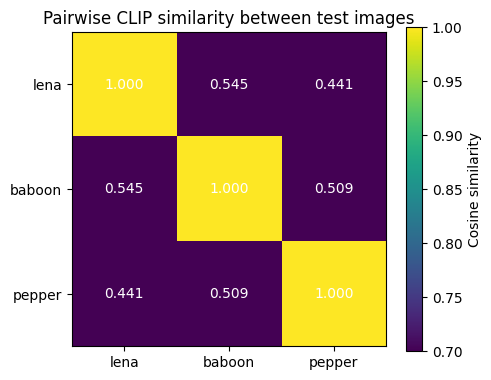

In [ ]:
# Compute pairwise cosine similarities
names = list(embeddings.keys())
n = len(names)
sim_matrix = np.zeros((n, n))

for i, ni in enumerate(names):
    for j, nj in enumerate(names):
        sim_matrix[i, j] = cosine_similarity(embeddings[ni], embeddings[nj])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(sim_matrix, vmin=0.7, vmax=1.0, cmap='viridis')
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(names); ax.set_yticklabels(names)
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{sim_matrix[i,j]:.3f}', ha='center', va='center', color='white', fontsize=10)
plt.colorbar(im, ax=ax, label='Cosine similarity')
ax.set_title('Pairwise CLIP similarity between test images')
plt.tight_layout()
plt.show()

## Visualising the Embedding Space with PCA

512 dimensions are impossible to visualise directly.
**PCA** (Principal Component Analysis) projects high-dimensional data to 2D while preserving
as much variance as possible — useful for quickly checking whether similar images cluster together.

Variance explained by 2 PCs: 100.0%


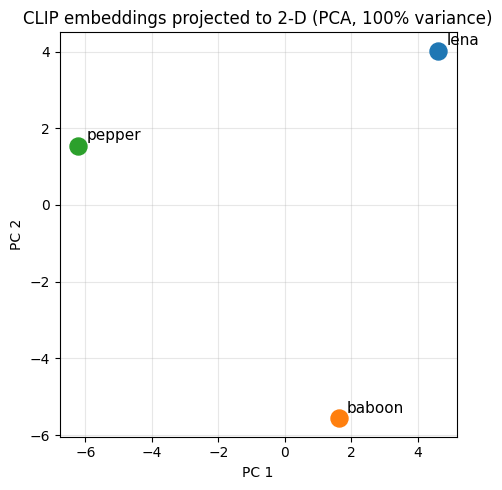

In [ ]:
from sklearn.decomposition import PCA

# Stack all embeddings into a matrix: shape (n_images, 512)
names_list = list(embeddings.keys())
X = np.stack([embeddings[n] for n in names_list])  # (3, 512)

# Project to 2D
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)   # (3, 2)

explained = pca.explained_variance_ratio_.sum() * 100
print(f'Variance explained by 2 PCs: {explained:.1f}%')

fig, ax = plt.subplots(figsize=(5, 5))
for i, name in enumerate(names_list):
    ax.scatter(*X_2d[i], s=150, zorder=3)
    ax.annotate(name, X_2d[i], textcoords='offset points', xytext=(6, 4), fontsize=11)
ax.set_title(f'CLIP embeddings projected to 2-D (PCA, {explained:.0f}% variance)')
ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Why Use Vectors for Face Recognition?

| Approach | Storage | Comparison | Scale |
|----------|---------|------------|-------|
| Raw pixels (512×512 RGB) | ~786 KB per face | pixel-by-pixel, slow | poor |
| Embedding (512 floats) | 2 KB per face | single dot product | excellent |

A cosine similarity between two 512-D vectors is just a dot product and two norms —
a handful of arithmetic operations. Comparing raw pixels involves ~786,000 comparisons.

More importantly, embeddings are **robust**: the same person under different lighting,
angle, or partial occlusion maps to nearby vectors. Pixel comparison would fail.